# 1. Use sklearn's PolynomialFeatures() to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2, and print the resulting feature matrix.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data = {
    'RAM': [4, 6, 8, 12, 6],
    'Storage': [64, 128, 128, 256, 64]
}
df = pd.DataFrame(data)

In [3]:
X = df[['RAM', 'Storage']]

In [5]:
poly = PolynomialFeatures(degree=2)

In [6]:
x_poly = poly.fit_transform(X)

In [7]:
print("Original Features")
print(X)
print("\nFeature Matrix (Degree 2)")
print(x_poly)

Original Features
   RAM  Storage
0    4       64
1    6      128
2    8      128
3   12      256
4    6       64

Feature Matrix (Degree 2)
[[1.0000e+00 4.0000e+00 6.4000e+01 1.6000e+01 2.5600e+02 4.0960e+03]
 [1.0000e+00 6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.0000e+00 8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [1.0000e+00 1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]
 [1.0000e+00 6.0000e+00 6.4000e+01 3.6000e+01 3.8400e+02 4.0960e+03]]


# 2. Train both a LinearRegression and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings versus number of reviews, then plot both predictions on the same chart to compare their fits.<br><br><em><strong>Hint:</strong> Use matplotlib for plotting and clearly label both curves.</em>

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
np.random.seed(42)
reviews = np.array([10, 50, 100, 200, 350, 500, 750, 1000, 1500, 2000]).reshape(-1, 1)
ratings = np.array([2.1, 2.5, 3.0, 3.5, 3.8, 4.0, 4.1, 4.5, 4.8, 4.9]).reshape(-1, 1)

In [11]:
linear_model = LinearRegression()
linear_model.fit(reviews, ratings)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
pred_linear = linear_model.predict(reviews)

In [13]:
poly_feat = PolynomialFeatures(degree=3)
reviews_poly = poly_feat.fit_transform(reviews)

In [14]:
poly_model = LinearRegression()
poly_model.fit(reviews_poly, ratings)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
pred_poly = poly_model.predict(reviews_poly)

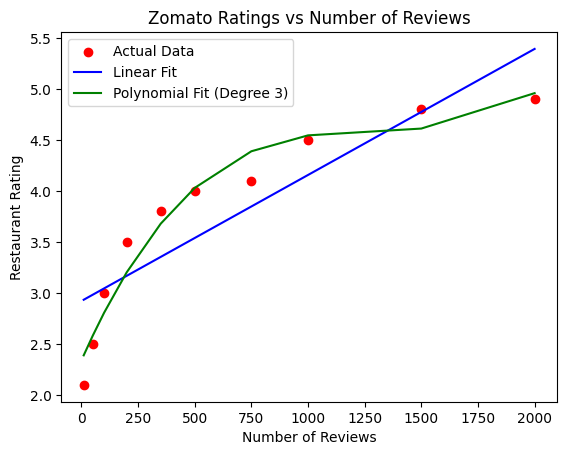

In [16]:
plt.scatter(reviews, ratings, color='red', label='Actual Data')
plt.plot(reviews, pred_linear, color='blue', label='Linear Fit')
plt.plot(reviews, pred_poly, color='green', label='Polynomial Fit (Degree 3)')

plt.title('Zomato Ratings vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant Rating')
plt.legend()
plt.show()

# 3. Given a dataset where the relationship between followers and posts for Instagram users is non-linear, fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [20]:
np.random.seed(42)
posts = np.random.randint(10, 500, 50).reshape(-1, 1)
followers = (posts ** 2) + np.random.normal(0, 10000, 50).reshape(-1, 1)

In [21]:
X_train, X_val, y_train, y_val = train_test_split(posts, followers, test_size=0.3, random_state=42)

In [22]:
train_errors = []
val_errors = []

In [23]:
degrees = [1, 2, 3, 4, 5]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_errors.append(mean_squared_error(y_val, model.predict(X_val_poly)))

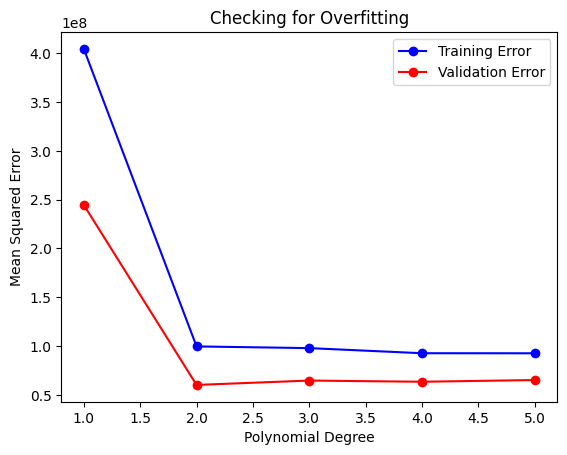

In [24]:
plt.plot(degrees, train_errors, label='Training Error', marker='o', color='blue')
plt.plot(degrees, val_errors, label='Validation Error', marker='o', color='red')
plt.title('Checking for Overfitting')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

# 4. Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, and compare the model's performance with and without regularization.<br><br><em><strong>Hint:</strong> Use Ridge from sklearn.linear_model and explain any difference in test error.</em>

In [25]:
from sklearn.linear_model import Ridge

In [26]:
np.random.seed(42)
X_data = np.random.rand(40, 2) * 10
y_data = 3 * (X_data[:, 0]**3) + 5 * (X_data[:, 1]**2) + np.random.normal(0, 50, 40)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

In [28]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [32]:
model_no_reg = LinearRegression()
model_no_reg.fit(X_train_poly, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
test_pred_no_reg = model_no_reg.predict(X_test_poly)

In [34]:
model_with_reg = Ridge(alpha=1.0)
model_with_reg.fit(X_train_poly, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [35]:
test_pred_with_reg = model_with_reg.predict(X_test_poly)

In [36]:
print("--- Without Regularization ---")
print("Test MSE:", mean_squared_error(y_test, test_pred_no_reg))

print("\n--- With Ridge Regularization ---")
print("Test MSE:", mean_squared_error(y_test, test_pred_with_reg))

--- Without Regularization ---
Test MSE: 6393.527274416709

--- With Ridge Regularization ---
Test MSE: 5518.6152788339605


**Without Regularization (Standard Polynomial Regression)**: The Test MSE is significantly higher. This happens because a degree 3 polynomial model is complex and tries too hard to perfectly fit every data point in the small training set. It captures random noise along with the actual price trends, leading to overfitting and poor performance on the unseen test data.    

**With Ridge Regularization (L2 Regularization)**: The Test MSE drops and becomes much lower. When we add Ridge(alpha=1.0), the model introduces a penalty to prevent the coefficients from growing too large. This forces the model to smooth out its predictions and ignore the random fluctuations in the training set.

# 5. Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, then run the code and explain in your own words how model degree affects bias and variance.

In [37]:
np.random.seed(0)
X = np.sort(np.random.rand(30, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 30)

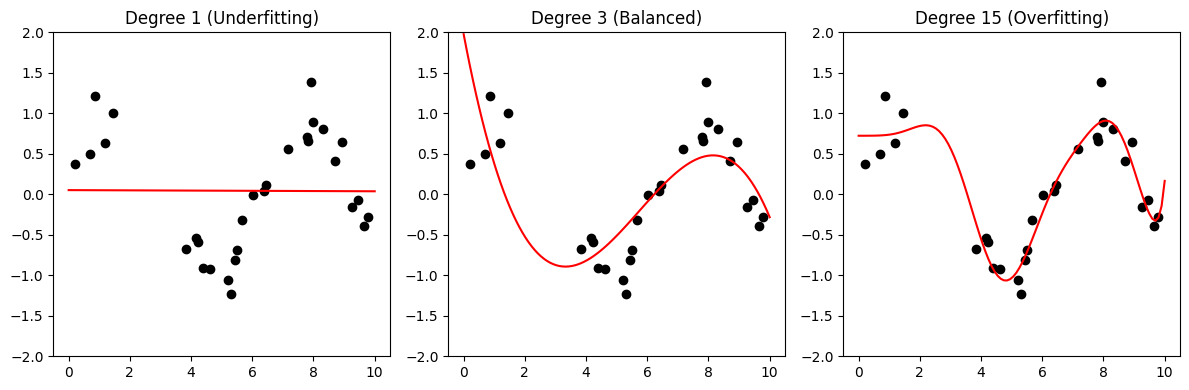

In [42]:
plt.figure(figsize=(12, 4))
degrees = [1, 3, 15] 
titles = ['Degree 1 (Underfitting)', 'Degree 3 (Balanced)', 'Degree 15 (Overfitting)']

for i, d in enumerate(degrees):
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    X_line = np.linspace(0, 10, 100).reshape(-1, 1)
    X_line_poly = poly.transform(X_line)
    y_line_pred = model.predict(X_line_poly)
    
    plt.subplot(1, 3, i + 1)
    plt.scatter(X, y, color='black', label='Data')
    plt.plot(X_line, y_line_pred, color='red', label='Prediction')
    plt.title(titles[i])
    plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

Degree 1 (Underfitting - High Bias, Low Variance): The model forces a rigid, straight line through a curved dataset. It is too simple to capture the actual trend of the data. This means it has High Bias (makes wrong assumptions about the data structure) but Low Variance (the line won't change drastically if we use different training data).

Degree 15 (Overfitting - Low Bias, High Variance): The model creates a highly complex, squiggly line that tries to pass through every single training point perfectly. This means it has Low Bias on the training set, but High Variance because the line waves wildly in between points. If we change even one data point, the entire shape of the curve will completely break, making it useless for new data.

Degree 3 (Balanced - Low Bias, Low Variance): This degree hits the perfect sweet spot. The curve smoothly tracks the underlying path of the data points without rushing to touch every single bit of random noise. It successfully minimizes both bias and variance, giving us a model that will perform well on new datasets.